# Kuramoto Model and Collective Synchronization
Submitted by **AMARNATH (MS22070)**

## Introduction

The **Kuramoto model**, introduced by **Yoshiki Kuramoto (1975)**, provides a simple mathematical framework to study such synchronization phenomena.

---

# Phase Oscillator Description

Each oscillator evolves on a limit cycle and can therefore be described only by its **phase variable**

$$
\theta_i(t)
$$

where  

- $\theta_i$ is the phase of the $i^{th}$ oscillator  
- $i = 1,2,\dots,N$

Each oscillator has a **natural frequency**

$$
\omega_i
$$

which is drawn from a probability distribution $g(\omega)$.

---

# Kuramoto Model Equation

For a system of $N$ oscillators with **all-to-all coupling**, the Kuramoto model is

$$
\frac{d\theta_i}{dt}
=
\omega_i
+
\frac{K}{N}
\sum_{j=1}^{N}
\sin(\theta_j-\theta_i)
$$

where $\theta_i$ is phase of oscillator $i$ , $\omega_i$ is corresponding natural frequency, $K$ is the coupling strength , $N$ is number of oscillators

---

# Frequency Distribution

The natural frequencies $\omega_i$ are drawn from a **continuous symmetric distribution**

$$
g(\omega)
$$

such that

$$
g(\omega) = g(-\omega)
$$

I have included:

- Gaussian distribution  
- Lorentzian distribution  
- Laplace distribution  

The symmetry ensures that the **mean frequency is zero**.

---

# Order Parameter

To quantify synchronization, Kuramoto introduced the **complex order parameter**

$$
re^{i\Psi}
=
\frac{1}{N}
\sum_{j=1}^{N}
e^{i\theta_j}
$$

where $r$ is magnitude of synchronization, $\Psi$ average phase 

### Interpretation

- $r = 0$ → completely incoherent state  
- $r = 1$ → perfect synchronization  

Geometrically, each oscillator corresponds to a **unit vector in the complex plane**

$$
e^{i\theta_j}
$$

The order parameter represents the **centroid of these vectors**.

---

# Mean Field Form of the Kuramoto Equation

Using

$$
\frac{1}{N}\sum_{j=1}^{N}\sin(\theta_j-\theta_i)
=
r\sin(\Psi-\theta_i)
$$

the Kuramoto equation becomes

$$
\frac{d\theta_i}{dt}
=
\omega_i
+
Kr
\sin(\Psi-\theta_i)
$$

Thus each oscillator interacts with the **collective mean field** rather than individual oscillators.

---

# Synchronization Transition

The system exhibits a **phase transition** depending on the coupling strength $K$.

### Weak Coupling

$$
K < K_c
$$

Oscillators evolve independently

$$
r \approx 0
$$


### Strong Coupling

$$
K > K_c
$$

A fraction of oscillators synchronize

$$
r > 0
$$




### Critical Coupling

Kuramoto showed that synchronization begins when

$$
K_c = \frac{2}{\pi g(0)}
$$

where

$$
g(0)
$$

is the value of the frequency distribution at zero.

---


# Numerical Simulation

To study the dynamics, the equations are solved 

$$
\frac{d\theta_i}{dt}
=
\omega_i
+
\frac{K}{N}\sum_j
\sin(\theta_j-\theta_i)
$$

The order parameter

$$
r(t)
=
\left|
\frac{1}{N}
\sum_{j=1}^{N}
e^{i\theta_j}
\right|
$$

is used to measure the degree of synchronization.

$$
r(t)
$$ shows how synchronization develops over time.

---

### Phase Distribution on the Unit Circle

Each oscillator is represented by

$$
(\cos\theta_i,\sin\theta_i)
$$
In General:
- Random distribution → incoherent state  
- Clustered points → synchronized state



In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [19]:
#parameters

N = 500
dt = 0.01
T = 50
steps = int(T/dt)
time = np.arange(steps)*dt

# initial phases
theta0 = np.random.uniform(0,2*np.pi,N)

# Kuramoto model

def kuramoto(omega, K):

    theta = theta0.copy()
    r_values = []

    for t in range(steps):

        # order parameter
        r = np.abs(np.mean(np.exp(1j*theta)))
        r_values.append(r)

        coupling = np.zeros(N)

        for i in range(N):
            coupling[i] = np.sum(np.sin(theta - theta[i]))

        dtheta = omega + (K/N)*coupling
        theta += dtheta*dt

    return r_values


# I have taken 3 different frequency distributions: Gaussian, Lorentzian and Laplace. 
# Then critical coupling Kc is calculated for each distribution and then the Kuramoto model is simulated for coupling values below and above Kc to observe the synchronization behavior.

# Gaussian distribution (sigma = 1)
omega_gauss = np.random.normal(0,1,N)

# Lorentzian distribution (gamma = 1)
omega_lor = np.clip(np.random.standard_cauchy(N), -10, 10)

# Laplace distribution (scale b = 1)
b = 1
omega_lap = np.random.lapalace(0,b,N)


# calculation of critical coupling Kc for each distribution

# Gaussian
g0_gauss = 1/np.sqrt(2*np.pi)
Kc_gauss = 2/(np.pi*g0_gauss)

# Lorentzian
gamma = 1
Kc_lor = 2*gamma

# Laplace
Kc_lap = 4*b/np.pi

print("Critical coupling values")
print("Gaussian Kc =", Kc_gauss)
print("Lorentzian Kc =", Kc_lor)
print("Laplace Kc =", Kc_lap)


#simulation

# Gaussian
r_gauss_low = kuramoto(omega_gauss,0.5*Kc_gauss)
r_gauss_high = kuramoto(omega_gauss,2*Kc_gauss)

# Lorentzian
r_lor_low = kuramoto(omega_lor,0.5*Kc_lor)
r_lor_high = kuramoto(omega_lor,2*Kc_lor)

# Laplace
r_lap_low = kuramoto(omega_lap,0.5*Kc_lap)
r_lap_high = kuramoto(omega_lap,2*Kc_lap)


Critical coupling values
Gaussian Kc = 1.5957691216057306
Lorentzian Kc = 2
Laplace Kc = 1.2732395447351628


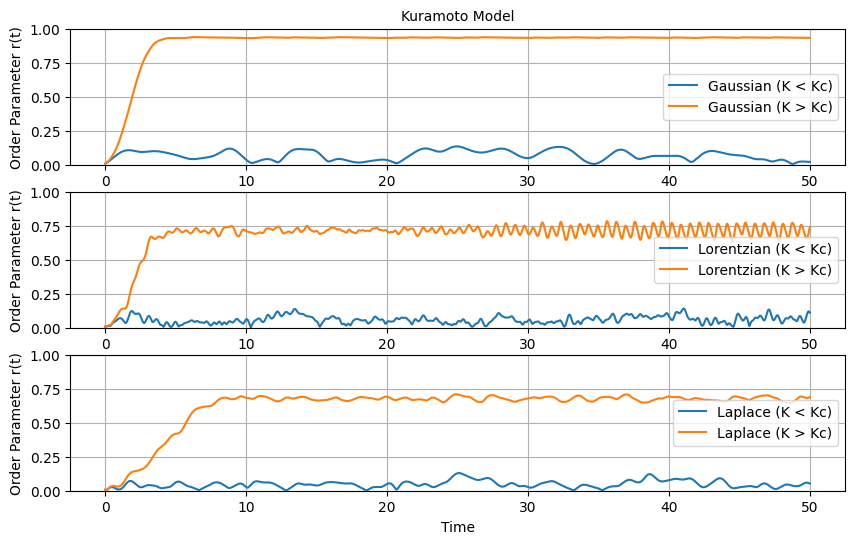

In [61]:
plt.figure(figsize=(10,6))

# Gaussian
plt.subplot(3,1,1)
plt.plot(time,r_gauss_low,label="Gaussian (K < Kc)")
plt.plot(time,r_gauss_high,label="Gaussian (K > Kc)")
plt.ylim(0,1)
plt.xlabel("Time")
plt.ylabel("Order Parameter r(t)")
plt.grid()
plt.legend(loc="center right")
plt.title("Kuramoto Model", fontsize=10)
# Lorentzian
plt.subplot(3,1,2)
plt.plot(time,r_lor_low,label="Lorentzian (K < Kc)")
plt.plot(time,r_lor_high,label="Lorentzian (K > Kc)")
plt.ylim(0,1)
plt.xlabel("Time")
plt.ylabel("Order Parameter r(t)")
plt.grid()
plt.legend(loc="center right")
# Laplace
plt.subplot(3,1,3)
plt.plot(time,r_lap_low,label="Laplace (K < Kc)")
plt.plot(time,r_lap_high,label="Laplace (K > Kc)")
plt.ylim(0,1)
plt.xlabel("Time")
plt.ylabel("Order Parameter r(t)")
plt.grid()
plt.legend(loc="center right")

plt.show()

In [48]:
# parameters
N = 500
dt = 0.01
T = 50
steps = int(T/dt)

# coupling strengths
K_values = np.linspace(0,4,20)


r_gauss = []
r_lor = []
r_lap = []

def rinf(omega, K):

    theta = np.random.uniform(0,2*np.pi,N)
    r_values = []

    for t in range(steps):

        r = np.abs(np.mean(np.exp(1j*theta)))
        r_values.append(r)

        coupling = np.zeros(N)

        for i in range(N):
            coupling[i] = np.sum(np.sin(theta - theta[i]))

        dtheta = omega + (K/N)*coupling
        theta += dtheta*dt

    # steady-state order parameter
    return np.mean(r_values[-200:])

# Gaussian
for K in K_values:
    r_gauss.append(rinf(omega_gauss, K))

# Lorentzian
for K in K_values:
    r_lor.append(rinf(omega_lor, K))

# Laplace
for K in K_values:
    r_lap.append(rinf(omega_lap, K))



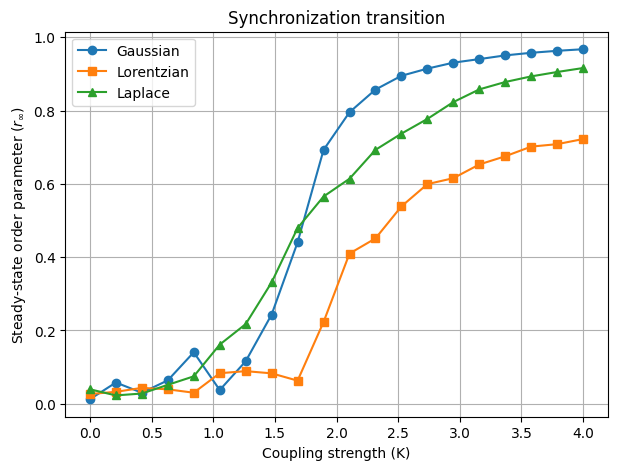

In [52]:
# Plot
plt.figure(figsize=(7,5))

plt.plot(K_values, r_gauss, 'o-', label="Gaussian")
plt.plot(K_values, r_lor, 's-', label="Lorentzian")
plt.plot(K_values, r_lap, '^-', label="Laplace")

plt.xlabel("Coupling strength (K)")
plt.ylabel("Steady-state order parameter ($r_\\infty$)")
plt.title("Synchronization transition")

plt.grid()
plt.legend()

plt.show()

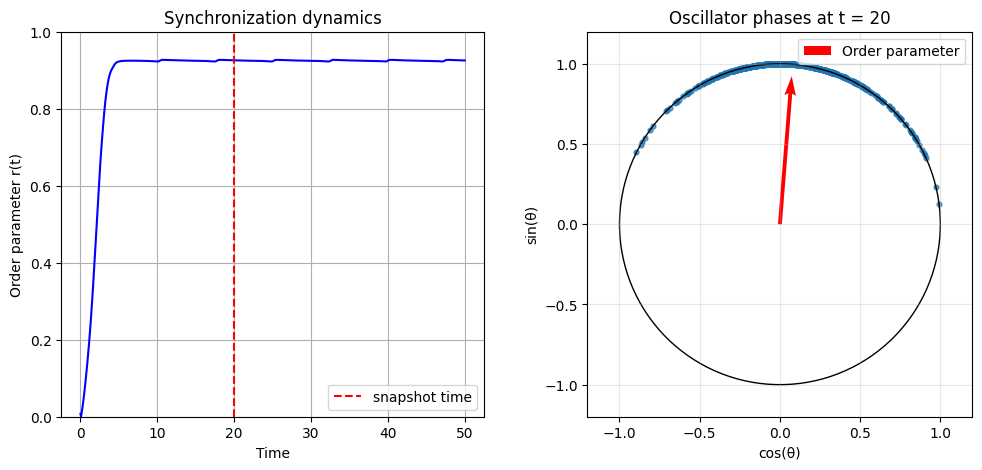

In [67]:
# Snapshot of state at any defined time

t_snap = 20          # time at which the circle state will be shown
K = 3.0              # coupling strength
distribution = "gaussian"   #  gaussian, lorentzian, laplace

#parameters

N = 500
dt = 0.01
T = 50
steps = int(T/dt)
time = np.arange(steps)*dt

snapshot_step = int(t_snap/dt)

# frequency distribution

if distribution == "gaussian":
    omega = np.random.normal(0,1,N)

elif distribution == "lorentzian":
    omega = np.clip(np.random.standard_cauchy(N),-10,10)

elif distribution == "laplace":
    omega = np.random.laplace(0,1,N)


# initial phase

theta = np.random.uniform(0,2*np.pi,N)

r_values = []

# simulation

theta_snapshot = None

for t in range(steps):

    # order parameter
    r = np.abs(np.mean(np.exp(1j*theta)))
    r_values.append(r)

    # store snapshot
    if t == snapshot_step:
        theta_snapshot = theta.copy()

    coupling = np.zeros(N)

    for i in range(N):
        coupling[i] = np.sum(np.sin(theta - theta[i]))

    dtheta = omega + (K/N)*coupling
    theta += dtheta*dt

# plot

fig, ax = plt.subplots(1,2,figsize=(12,5))

# r(t) plot
ax[0].plot(time,r_values,color="blue")
ax[0].axvline(t_snap,color="red",linestyle="--",label="snapshot time")

ax[0].set_xlabel("Time")
ax[0].set_ylabel("Order parameter r(t)")
ax[0].set_title("Synchronization dynamics")
ax[0].set_ylim(0,1)
ax[0].legend()
ax[0].grid()

# circle plot
x = np.cos(theta_snapshot)
y = np.sin(theta_snapshot)

ax[1].scatter(x, y, s=12, alpha=0.7)

circle = plt.Circle((0,0),1,fill=False,color="black")
ax[1].add_artist(circle)

order_parameter = np.mean(np.exp(1j*theta_snapshot))
r = np.abs(order_parameter)
psi = np.angle(order_parameter)

ax[1].quiver(0, 0, r*np.cos(psi), r*np.sin(psi),
             angles='xy', scale_units='xy', scale=1,
             color='red', width=0.01,
             label="Order parameter")

ax[1].set_aspect('equal')

ax[1].set_xlim(-1.2,1.2)
ax[1].set_ylim(-1.2,1.2)

ax[1].set_xlabel("cos(θ)")
ax[1].set_ylabel("sin(θ)")
ax[1].set_title(f"Oscillator phases at t = {t_snap}")

ax[1].legend()
ax[1].grid(alpha=0.3)